In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

data_file = Path("clean_manufacturing_dataset_v1.csv")

print("File exists:", data_file.exists())

manufacturing_data = pd.read_csv(data_file)

print("Dataset loaded successfully.")
print("Original dataset shape:", manufacturing_data.shape)

manufacturing_data.head()

File exists: True
Dataset loaded successfully.
Original dataset shape: (10117, 41)


,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,operator_id,operator_name,experience_level,skill_category,machine_id,runtime_hours,downtime_minutes,maintenance_flag,machine_status,maintenance_id,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp,start_datetime,end_datetime,temperature_was_missing,humidity_was_missing,timestamp_was_missing,efficiency_above_100_flag,invalid_production_flag,invalid_runtime_flag,invalid_downtime_flag,invalid_humidity_flag
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,No maintenance,0.0,Not applicable,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00,2024-01-01 06:00:00,2024-01-01 14:00:00,0,0,0,0,0,0,0,0
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,No maintenance,0.0,Not applicable,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00,2024-01-01 06:00:00,2024-01-01 14:00:00,0,0,0,0,0,0,0,0
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,No maintenance,0.0,Not applicable,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00,2024-01-01 06:00:00,2024-01-01 14:00:00,0,0,0,0,0,0,0,0
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,No maintenance,0.0,Not applicable,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00,2024-01-01 06:00:00,2024-01-01 14:00:00,0,0,0,0,0,0,0,0
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,No maintenance,0.0,Not applicable,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00,2024-01-01 06:00:00,2024-01-01 14:00:00,0,0,0,0,0,0,0,0


In [3]:
list(Path(".").glob("*.csv"))

[WindowsPath('cleaned_manufacturing_dataset_v1.csv'),
 WindowsPath('clean_manufacturing_dataset_v1.csv'),
 WindowsPath('extracted dataset file.csv'),
 WindowsPath('feature_engineered_manufacturing_dataset.csv'),
 WindowsPath('feature_engineering_documentation.csv'),
 WindowsPath('raw_manufacturing_dataset.csv')]

In [4]:
feature_data = manufacturing_data.copy()

print("Working copy created.")
print("Shape:", feature_data.shape)

Working copy created.
Shape: (10117, 41)


In [5]:
feature_data["date"] = pd.to_datetime(
    feature_data["date"],
    errors="coerce"
)

for column in [
    "start_datetime",
    "end_datetime",
    "timestamp"
]:
    feature_data[column] = pd.to_datetime(
        feature_data[column],
        errors="coerce"
    )

feature_data[
    [
        "date",
        "start_datetime",
        "end_datetime",
        "timestamp"
    ]
].dtypes

date              datetime64[us]
start_datetime    datetime64[us]
end_datetime      datetime64[us]
timestamp         datetime64[us]
dtype: object

In [6]:
feature_data["day_of_week"] = (
    feature_data["date"].dt.day_name()
)

feature_data["day_number"] = (
    feature_data["date"].dt.dayofweek
)

feature_data["is_weekend"] = (
    feature_data["day_number"]
    .isin([5, 6])
    .astype(int)
)

feature_data["month"] = (
    feature_data["date"].dt.month
)

feature_data["shift_start_hour"] = (
    feature_data["start_datetime"].dt.hour
)

feature_data["shift_duration_hours"] = (
    feature_data["end_datetime"]
    - feature_data["start_datetime"]
).dt.total_seconds() / 3600

feature_data[
    [
        "date",
        "day_of_week",
        "day_number",
        "is_weekend",
        "month",
        "shift_start_hour",
        "shift_duration_hours"
    ]
].head(10)

,date,day_of_week,day_number,is_weekend,month,shift_start_hour,shift_duration_hours
0,2024-01-01,Monday,0,0,1,6,8.0
1,2024-01-01,Monday,0,0,1,6,8.0
2,2024-01-01,Monday,0,0,1,6,8.0
3,2024-01-01,Monday,0,0,1,6,8.0
4,2024-01-01,Monday,0,0,1,6,8.0
5,2024-01-01,Monday,0,0,1,6,8.0
6,2024-01-01,Monday,0,0,1,6,8.0
7,2024-01-01,Monday,0,0,1,6,8.0
8,2024-01-01,Monday,0,0,1,6,8.0
9,2024-01-01,Monday,0,0,1,6,8.0


In [7]:
safe_units = (
    feature_data["units_produced"]
    .replace(0, np.nan)
)

safe_runtime = (
    feature_data["runtime_hours"]
    .replace(0, np.nan)
)

feature_data["good_units"] = (
    feature_data["units_produced"]
    - feature_data["defect_count"]
).clip(lower=0)

feature_data["defect_rate_pct"] = (
    feature_data["defect_count"]
    / safe_units
    * 100
).fillna(0)

feature_data["quality_rate_pct"] = (
    feature_data["good_units"]
    / safe_units
    * 100
).fillna(0)

feature_data["production_rate_per_hour"] = (
    feature_data["units_produced"]
    / safe_runtime
).fillna(0)

feature_data["good_units_per_hour"] = (
    feature_data["good_units"]
    / safe_runtime
).fillna(0)

feature_data[
    [
        "units_produced",
        "defect_count",
        "good_units",
        "defect_rate_pct",
        "quality_rate_pct",
        "production_rate_per_hour",
        "good_units_per_hour"
    ]
].head(10).round(2)

,units_produced,defect_count,good_units,defect_rate_pct,quality_rate_pct,production_rate_per_hour,good_units_per_hour
0,929,20,909,2.15,97.85,128.31,125.55
1,929,20,909,2.15,97.85,128.31,125.55
2,929,20,909,2.15,97.85,128.31,125.55
3,929,20,909,2.15,97.85,128.31,125.55
4,929,20,909,2.15,97.85,128.31,125.55
5,929,20,909,2.15,97.85,128.31,125.55
6,929,20,909,2.15,97.85,128.31,125.55
7,929,20,909,2.15,97.85,128.31,125.55
8,929,20,909,2.15,97.85,128.31,125.55
9,929,20,909,2.15,97.85,128.31,125.55


In [8]:
feature_data["runtime_minutes"] = (
    feature_data["runtime_hours"] * 60
)

feature_data["available_minutes"] = (
    480 - feature_data["downtime_minutes"]
).clip(lower=0)

feature_data["machine_utilization_pct"] = (
    feature_data["runtime_minutes"]
    / 480
    * 100
).clip(0, 100)

feature_data["downtime_percentage"] = (
    feature_data["downtime_minutes"]
    / 480
    * 100
).clip(0, 100)

feature_data["availability_pct"] = (
    feature_data["available_minutes"]
    / 480
    * 100
).clip(0, 100)

feature_data["total_stoppage_minutes"] = (
    feature_data["downtime_minutes"]
    + feature_data["maintenance_downtime"].fillna(0)
)

feature_data[
    [
        "runtime_minutes",
        "available_minutes",
        "machine_utilization_pct",
        "downtime_percentage",
        "availability_pct",
        "total_stoppage_minutes"
    ]
].head(10).round(2)

,runtime_minutes,available_minutes,machine_utilization_pct,downtime_percentage,availability_pct,total_stoppage_minutes
0,434.4,464.61,90.5,3.21,96.79,15.39
1,434.4,464.61,90.5,3.21,96.79,15.39
2,434.4,464.61,90.5,3.21,96.79,15.39
3,434.4,464.61,90.5,3.21,96.79,15.39
4,434.4,464.61,90.5,3.21,96.79,15.39
5,434.4,464.61,90.5,3.21,96.79,15.39
6,434.4,464.61,90.5,3.21,96.79,15.39
7,434.4,464.61,90.5,3.21,96.79,15.39
8,434.4,464.61,90.5,3.21,96.79,15.39
9,434.4,464.61,90.5,3.21,96.79,15.39


In [9]:
feature_data["estimated_oee_pct"] = (
    feature_data["availability_pct"] / 100
    * feature_data["machine_utilization_pct"] / 100
    * feature_data["quality_rate_pct"] / 100
    * 100
).clip(0, 100)

feature_data[
    [
        "availability_pct",
        "machine_utilization_pct",
        "quality_rate_pct",
        "estimated_oee_pct"
    ]
].head(10).round(2)

,availability_pct,machine_utilization_pct,quality_rate_pct,estimated_oee_pct
0,96.79,90.5,97.85,85.71
1,96.79,90.5,97.85,85.71
2,96.79,90.5,97.85,85.71
3,96.79,90.5,97.85,85.71
4,96.79,90.5,97.85,85.71
5,96.79,90.5,97.85,85.71
6,96.79,90.5,97.85,85.71
7,96.79,90.5,97.85,85.71
8,96.79,90.5,97.85,85.71
9,96.79,90.5,97.85,85.71


In [10]:
median_temperature = (
    feature_data["temperature"].median()
)

median_humidity = (
    feature_data["humidity"].median()
)

feature_data["temperature_deviation"] = (
    feature_data["temperature"]
    - median_temperature
).abs()

feature_data["humidity_deviation"] = (
    feature_data["humidity"]
    - median_humidity
).abs()

feature_data["machine_issue_flag"] = (
    feature_data["machine_status"]
    .eq("Issues")
    .astype(int)
)

feature_data[
    [
        "temperature",
        "temperature_deviation",
        "humidity",
        "humidity_deviation",
        "machine_status",
        "machine_issue_flag"
    ]
].head(10).round(2)

,temperature,temperature_deviation,humidity,humidity_deviation,machine_status,machine_issue_flag
0,22.3,2.6,49.9,4.8,Operational,0
1,22.3,2.6,49.9,4.8,Operational,0
2,22.3,2.6,49.9,4.8,Operational,0
3,22.3,2.6,49.9,4.8,Operational,0
4,22.3,2.6,49.9,4.8,Operational,0
5,22.3,2.6,49.9,4.8,Operational,0
6,22.3,2.6,49.9,4.8,Operational,0
7,22.3,2.6,49.9,4.8,Operational,0
8,22.3,2.6,49.9,4.8,Operational,0
9,22.3,2.6,49.9,4.8,Operational,0


In [11]:
median_experience = (
    feature_data["experience_level"].median()
)

feature_data["experienced_operator_flag"] = (
    feature_data["experience_level"]
    >= median_experience
).astype(int)

feature_data["experience_runtime_interaction"] = (
    feature_data["experience_level"]
    * feature_data["runtime_hours"]
)

feature_data[
    [
        "operator_id",
        "experience_level",
        "experienced_operator_flag",
        "runtime_hours",
        "experience_runtime_interaction"
    ]
].head(10)

,operator_id,experience_level,experienced_operator_flag,runtime_hours,experience_runtime_interaction
0,OP_019,7,1,7.24,50.68
1,OP_019,7,1,7.24,50.68
2,OP_019,7,1,7.24,50.68
3,OP_019,7,1,7.24,50.68
4,OP_019,7,1,7.24,50.68
5,OP_019,7,1,7.24,50.68
6,OP_019,7,1,7.24,50.68
7,OP_019,7,1,7.24,50.68
8,OP_019,7,1,7.24,50.68
9,OP_019,7,1,7.24,50.68


In [12]:
machine_daily = (
    feature_data
    .groupby(
        ["machine_id", "date"],
        as_index=False
    )
    .agg(
        daily_units=(
            "units_produced",
            "mean"
        ),
        daily_downtime=(
            "downtime_minutes",
            "mean"
        ),
        daily_defect_rate=(
            "defect_rate_pct",
            "mean"
        )
    )
    .sort_values(
        ["machine_id", "date"]
    )
)

historical_features = {
    "daily_units":
        "machine_prior_avg_units",
    "daily_downtime":
        "machine_prior_avg_downtime",
    "daily_defect_rate":
        "machine_prior_avg_defect_rate"
}

for source, new_feature in historical_features.items():
    machine_daily[new_feature] = (
        machine_daily
        .groupby("machine_id")[source]
        .transform(
            lambda values:
            values.shift(1).expanding().mean()
        )
    )

feature_data = feature_data.merge(
    machine_daily[
        [
            "machine_id",
            "date",
            "machine_prior_avg_units",
            "machine_prior_avg_downtime",
            "machine_prior_avg_defect_rate"
        ]
    ],
    on=["machine_id", "date"],
    how="left"
)

historical_columns = [
    "machine_prior_avg_units",
    "machine_prior_avg_downtime",
    "machine_prior_avg_defect_rate"
]

for column in historical_columns:
    feature_data[column] = (
        feature_data[column]
        .fillna(feature_data[column].median())
    )

feature_data[
    [
        "machine_id",
        "date",
        "machine_prior_avg_units",
        "machine_prior_avg_downtime",
        "machine_prior_avg_defect_rate"
    ]
].head(15).round(2)

C:\Users\User\AppData\Local\Temp\ipykernel_7264\3786738813.py:79: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].head(15).round(2)


,machine_id,date,machine_prior_avg_units,machine_prior_avg_downtime,machine_prior_avg_defect_rate
0,MC_001,2024-01-01,661.3,35.42,3.47
1,MC_001,2024-01-01,661.3,35.42,3.47
2,MC_001,2024-01-01,661.3,35.42,3.47
3,MC_001,2024-01-01,661.3,35.42,3.47
4,MC_001,2024-01-01,661.3,35.42,3.47
5,MC_001,2024-01-01,661.3,35.42,3.47
6,MC_001,2024-01-01,661.3,35.42,3.47
7,MC_001,2024-01-01,661.3,35.42,3.47
8,MC_001,2024-01-01,661.3,35.42,3.47
9,MC_001,2024-01-01,661.3,35.42,3.47


In [13]:
new_features = [
    column
    for column in feature_data.columns
    if column not in manufacturing_data.columns
]

feature_summary = pd.DataFrame({
    "Measure": [
        "Original rows",
        "Original columns",
        "Feature-engineered rows",
        "Feature-engineered columns",
        "New features created"
    ],
    "Result": [
        manufacturing_data.shape[0],
        manufacturing_data.shape[1],
        feature_data.shape[0],
        feature_data.shape[1],
        len(new_features)
    ]
})

feature_summary

,Measure,Result
0,Original rows,10117
1,Original columns,41
2,Feature-engineered rows,10117
3,Feature-engineered columns,67
4,New features created,26


In [14]:
pd.DataFrame({
    "New engineered feature": new_features
})

,New engineered feature
0,day_of_week
1,day_number
2,is_weekend
3,month
4,shift_start_hour
5,shift_duration_hours
6,good_units
7,defect_rate_pct
8,quality_rate_pct
9,production_rate_per_hour


In [15]:
validation_report = pd.DataFrame({
    "Check": [
        "Dataset rows preserved",
        "Duplicate rows",
        "Missing values in new features",
        "Infinite numerical values",
        "Negative good-unit values",
        "Defect rates outside 0–100%",
        "Utilisation outside 0–100%",
        "Estimated OEE outside 0–100%"
    ],
    "Result": [
        feature_data.shape[0]
        == manufacturing_data.shape[0],

        feature_data.duplicated().sum(),

        feature_data[
            new_features
        ].isna().sum().sum(),

        np.isinf(
            feature_data.select_dtypes(
                include=np.number
            )
        ).sum().sum(),

        (
            feature_data["good_units"] < 0
        ).sum(),

        (
            ~feature_data["defect_rate_pct"]
            .between(0, 100)
        ).sum(),

        (
            ~feature_data[
                "machine_utilization_pct"
            ].between(0, 100)
        ).sum(),

        (
            ~feature_data[
                "estimated_oee_pct"
            ].between(0, 100)
        ).sum()
    ]
})

validation_report

,Check,Result
0,Dataset rows preserved,True
1,Duplicate rows,0
2,Missing values in new features,0
3,Infinite numerical values,0
4,Negative good-unit values,0
5,Defect rates outside 0–100%,0
6,Utilisation outside 0–100%,0
7,Estimated OEE outside 0–100%,0


In [16]:
engineered_numeric_features = (
    feature_data[new_features]
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

feature_correlations = (
    feature_data[
        engineered_numeric_features
        + ["shift_efficiency_score"]
    ]
    .corr(numeric_only=True)[
        "shift_efficiency_score"
    ]
    .drop("shift_efficiency_score")
    .sort_values(
        key=abs,
        ascending=False
    )
    .rename("correlation")
    .to_frame()
)

feature_correlations.head(15).round(3)

,correlation
shift_start_hour,-0.945
good_units,0.927
estimated_oee_pct,0.927
good_units_per_hour,0.922
production_rate_per_hour,0.922
machine_utilization_pct,0.916
runtime_minutes,0.916
downtime_percentage,-0.916
available_minutes,0.916
availability_pct,0.916


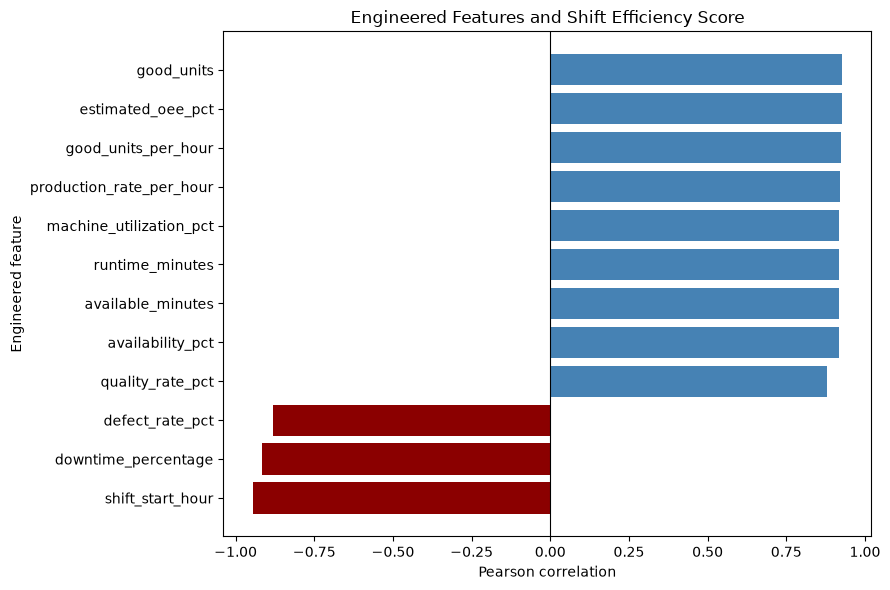

In [17]:
top_correlations = (
    feature_correlations
    .head(12)
    .sort_values("correlation")
)

plt.figure(figsize=(9, 6))

colors = [
    "darkred" if value < 0 else "steelblue"
    for value in top_correlations["correlation"]
]

plt.barh(
    top_correlations.index,
    top_correlations["correlation"],
    color=colors
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.title(
    "Engineered Features and Shift Efficiency Score"
)
plt.xlabel("Pearson correlation")
plt.ylabel("Engineered feature")
plt.tight_layout()
plt.show()

In [18]:
feature_documentation = pd.DataFrame([
    ["good_units", "Production", "Units produced minus defects", "Represents usable output."],
    ["defect_rate_pct", "Quality", "Defects divided by total output × 100", "Measures the proportion of defective production."],
    ["quality_rate_pct", "Quality", "Good units divided by output × 100", "Measures the proportion of acceptable production."],
    ["production_rate_per_hour", "Production", "Units produced divided by runtime", "Standardises output by operating time."],
    ["good_units_per_hour", "Production", "Good units divided by runtime", "Measures productive, non-defective output."],
    ["runtime_minutes", "Machine", "Runtime hours multiplied by 60", "Creates a common minutes-based measurement."],
    ["available_minutes", "Machine", "480 minus downtime", "Estimates productive time available during a shift."],
    ["machine_utilization_pct", "Machine", "Runtime minutes divided by 480 × 100", "Estimates use of scheduled shift capacity."],
    ["downtime_percentage", "Machine", "Downtime divided by 480 × 100", "Standardises production stoppages."],
    ["availability_pct", "Machine", "Available minutes divided by 480 × 100", "Measures estimated equipment availability."],
    ["total_stoppage_minutes", "Machine", "Downtime plus maintenance downtime", "Combines recorded sources of production stoppage."],
    ["estimated_oee_pct", "Machine", "Availability × utilisation × quality", "Provides an approximate composite performance indicator."],
    ["temperature_deviation", "Environment", "Absolute distance from median temperature", "Captures unusual temperature conditions."],
    ["humidity_deviation", "Environment", "Absolute distance from median humidity", "Captures unusual humidity conditions."],
    ["machine_issue_flag", "Operational", "Issues = 1; otherwise 0", "Creates a model-ready machine-condition indicator."],
    ["experienced_operator_flag", "Workforce", "Experience at or above median = 1", "Separates relatively experienced operators."],
    ["experience_runtime_interaction", "Workforce", "Experience level multiplied by runtime", "Captures the combined workforce-runtime effect."],
    ["day_of_week", "Time", "Day name extracted from date", "Captures weekly patterns."],
    ["day_number", "Time", "Monday = 0 through Sunday = 6", "Provides a numerical day representation."],
    ["is_weekend", "Time", "Saturday or Sunday = 1", "Distinguishes weekend operations."],
    ["month", "Time", "Month extracted from date", "Supports later seasonal analysis."],
    ["shift_start_hour", "Time", "Hour extracted from start datetime", "Represents shift timing."],
    ["shift_duration_hours", "Time", "End datetime minus start datetime", "Measures scheduled shift length."],
    ["machine_prior_avg_units", "Historical", "Mean units from earlier recorded dates", "Represents previous machine output."],
    ["machine_prior_avg_downtime", "Historical", "Mean downtime from earlier dates", "Represents previous machine stoppage behaviour."],
    ["machine_prior_avg_defect_rate", "Historical", "Mean defect rate from earlier dates", "Represents previous machine quality performance."]
], columns=[
    "Feature",
    "Category",
    "Transformation",
    "Reason"
])

feature_documentation

,Feature,Category,Transformation,Reason
0,good_units,Production,Units produced minus defects,Represents usable output.
1,defect_rate_pct,Quality,Defects divided by total output × 100,Measures the proportion of defective production.
2,quality_rate_pct,Quality,Good units divided by output × 100,Measures the proportion of acceptable production.
3,production_rate_per_hour,Production,Units produced divided by runtime,Standardises output by operating time.
4,good_units_per_hour,Production,Good units divided by runtime,"Measures productive, non-defective output."
5,runtime_minutes,Machine,Runtime hours multiplied by 60,Creates a common minutes-based measurement.
6,available_minutes,Machine,480 minus downtime,Estimates productive time available during a s...
7,machine_utilization_pct,Machine,Runtime minutes divided by 480 × 100,Estimates use of scheduled shift capacity.
8,downtime_percentage,Machine,Downtime divided by 480 × 100,Standardises production stoppages.
9,availability_pct,Machine,Available minutes divided by 480 × 100,Measures estimated equipment availability.


In [19]:
datetime_columns = [
    "date",
    "start_datetime",
    "end_datetime",
    "timestamp"
]

for column in datetime_columns:
    feature_data[column] = (
        feature_data[column]
        .dt.strftime("%Y-%m-%d %H:%M:%S")
    )

In [20]:
output_file = Path(
    "feature_engineered_manufacturing_dataset.csv"
)

documentation_file = Path(
    "feature_engineering_documentation.csv"
)

feature_data.to_csv(
    output_file,
    index=False
)

feature_documentation.to_csv(
    documentation_file,
    index=False
)

print("Dataset exported:", output_file)
print("Documentation exported:", documentation_file)
print("Final dataset shape:", feature_data.shape)
print("Dataset file exists:", output_file.exists())
print(
    "File size:",
    round(output_file.stat().st_size / 1024 / 1024, 2),
    "MB"
)

Dataset exported: feature_engineered_manufacturing_dataset.csv
Documentation exported: feature_engineering_documentation.csv
Final dataset shape: (10117, 67)
Dataset file exists: True
File size: 5.61 MB


In [21]:
print("Original dataset shape:", manufacturing_data.shape)
print("Original number of rows:", manufacturing_data.shape[0])
print("Original number of columns:", manufacturing_data.shape[1])

Original dataset shape: (10117, 41)
Original number of rows: 10117
Original number of columns: 41


In [22]:
feature_categories = pd.DataFrame({
    "Feature category": [
        "Time-based",
        "Production efficiency",
        "Quality performance",
        "Machine performance",
        "Operational/environmental",
        "Workforce",
        "Historical performance"
    ],
    "Purpose": [
        "Capture calendar and shift-timing patterns",
        "Measure output relative to productive time",
        "Measure defective and acceptable production",
        "Represent utilisation, downtime and availability",
        "Represent machine condition and environmental variation",
        "Capture operator experience effects",
        "Represent earlier machine behaviour"
    ]
})

feature_categories

,Feature category,Purpose
0,Time-based,Capture calendar and shift-timing patterns
1,Production efficiency,Measure output relative to productive time
2,Quality performance,Measure defective and acceptable production
3,Machine performance,"Represent utilisation, downtime and availability"
4,Operational/environmental,Represent machine condition and environmental ...
5,Workforce,Capture operator experience effects
6,Historical performance,Represent earlier machine behaviour


In [23]:
feature_data[
    [
        "units_produced",
        "defect_count",
        "good_units",
        "runtime_hours",
        "production_rate_per_hour",
        "good_units_per_hour"
    ]
].head(10).round(2)

,units_produced,defect_count,good_units,runtime_hours,production_rate_per_hour,good_units_per_hour
0,929,20,909,7.24,128.31,125.55
1,929,20,909,7.24,128.31,125.55
2,929,20,909,7.24,128.31,125.55
3,929,20,909,7.24,128.31,125.55
4,929,20,909,7.24,128.31,125.55
5,929,20,909,7.24,128.31,125.55
6,929,20,909,7.24,128.31,125.55
7,929,20,909,7.24,128.31,125.55
8,929,20,909,7.24,128.31,125.55
9,929,20,909,7.24,128.31,125.55


In [24]:
feature_data[
    [
        "units_produced",
        "defect_count",
        "good_units",
        "defect_rate_pct",
        "quality_rate_pct",
        "inspection_result"
    ]
].head(10).round(2)

,units_produced,defect_count,good_units,defect_rate_pct,quality_rate_pct,inspection_result
0,929,20,909,2.15,97.85,Rework
1,929,20,909,2.15,97.85,Accepted
2,929,20,909,2.15,97.85,Rework
3,929,20,909,2.15,97.85,Rework
4,929,20,909,2.15,97.85,Rework
5,929,20,909,2.15,97.85,Accepted
6,929,20,909,2.15,97.85,Rework
7,929,20,909,2.15,97.85,Rework
8,929,20,909,2.15,97.85,Accepted
9,929,20,909,2.15,97.85,Rework


In [25]:
feature_data[
    [
        "runtime_minutes",
        "available_minutes",
        "machine_utilization_pct",
        "downtime_percentage",
        "availability_pct",
        "total_stoppage_minutes"
    ]
].head(10).round(2)

,runtime_minutes,available_minutes,machine_utilization_pct,downtime_percentage,availability_pct,total_stoppage_minutes
0,434.4,464.61,90.5,3.21,96.79,15.39
1,434.4,464.61,90.5,3.21,96.79,15.39
2,434.4,464.61,90.5,3.21,96.79,15.39
3,434.4,464.61,90.5,3.21,96.79,15.39
4,434.4,464.61,90.5,3.21,96.79,15.39
5,434.4,464.61,90.5,3.21,96.79,15.39
6,434.4,464.61,90.5,3.21,96.79,15.39
7,434.4,464.61,90.5,3.21,96.79,15.39
8,434.4,464.61,90.5,3.21,96.79,15.39
9,434.4,464.61,90.5,3.21,96.79,15.39


In [27]:
feature_data[
    [
        "availability_pct",
        "machine_utilization_pct",
        "quality_rate_pct",
        "estimated_oee_pct"
    ]
].head(10).round(2)

,availability_pct,machine_utilization_pct,quality_rate_pct,estimated_oee_pct
0,96.79,90.5,97.85,85.71
1,96.79,90.5,97.85,85.71
2,96.79,90.5,97.85,85.71
3,96.79,90.5,97.85,85.71
4,96.79,90.5,97.85,85.71
5,96.79,90.5,97.85,85.71
6,96.79,90.5,97.85,85.71
7,96.79,90.5,97.85,85.71
8,96.79,90.5,97.85,85.71
9,96.79,90.5,97.85,85.71


In [28]:
feature_data[
    [
        "machine_status",
        "machine_issue_flag",
        "temperature",
        "temperature_deviation",
        "humidity",
        "humidity_deviation"
    ]
].head(10).round(2)

,machine_status,machine_issue_flag,temperature,temperature_deviation,humidity,humidity_deviation
0,Operational,0,22.3,2.6,49.9,4.8
1,Operational,0,22.3,2.6,49.9,4.8
2,Operational,0,22.3,2.6,49.9,4.8
3,Operational,0,22.3,2.6,49.9,4.8
4,Operational,0,22.3,2.6,49.9,4.8
5,Operational,0,22.3,2.6,49.9,4.8
6,Operational,0,22.3,2.6,49.9,4.8
7,Operational,0,22.3,2.6,49.9,4.8
8,Operational,0,22.3,2.6,49.9,4.8
9,Operational,0,22.3,2.6,49.9,4.8


In [29]:
feature_data[
    [
        "operator_id",
        "experience_level",
        "experienced_operator_flag",
        "runtime_hours",
        "experience_runtime_interaction"
    ]
].head(10)

,operator_id,experience_level,experienced_operator_flag,runtime_hours,experience_runtime_interaction
0,OP_019,7,1,7.24,50.68
1,OP_019,7,1,7.24,50.68
2,OP_019,7,1,7.24,50.68
3,OP_019,7,1,7.24,50.68
4,OP_019,7,1,7.24,50.68
5,OP_019,7,1,7.24,50.68
6,OP_019,7,1,7.24,50.68
7,OP_019,7,1,7.24,50.68
8,OP_019,7,1,7.24,50.68
9,OP_019,7,1,7.24,50.68


In [30]:
feature_data[
    [
        "date",
        "day_of_week",
        "day_number",
        "is_weekend",
        "month",
        "shift_start_hour",
        "shift_duration_hours"
    ]
].head(10)

,date,day_of_week,day_number,is_weekend,month,shift_start_hour,shift_duration_hours
0,2024-01-01 00:00:00,Monday,0,0,1,6,8.0
1,2024-01-01 00:00:00,Monday,0,0,1,6,8.0
2,2024-01-01 00:00:00,Monday,0,0,1,6,8.0
3,2024-01-01 00:00:00,Monday,0,0,1,6,8.0
4,2024-01-01 00:00:00,Monday,0,0,1,6,8.0
5,2024-01-01 00:00:00,Monday,0,0,1,6,8.0
6,2024-01-01 00:00:00,Monday,0,0,1,6,8.0
7,2024-01-01 00:00:00,Monday,0,0,1,6,8.0
8,2024-01-01 00:00:00,Monday,0,0,1,6,8.0
9,2024-01-01 00:00:00,Monday,0,0,1,6,8.0


In [31]:
feature_data[
    [
        "machine_id",
        "date",
        "machine_prior_avg_units",
        "machine_prior_avg_downtime",
        "machine_prior_avg_defect_rate"
    ]
].head(15).round(2)

,machine_id,date,machine_prior_avg_units,machine_prior_avg_downtime,machine_prior_avg_defect_rate
0,MC_001,2024-01-01 00:00:00,661.3,35.42,3.47
1,MC_001,2024-01-01 00:00:00,661.3,35.42,3.47
2,MC_001,2024-01-01 00:00:00,661.3,35.42,3.47
3,MC_001,2024-01-01 00:00:00,661.3,35.42,3.47
4,MC_001,2024-01-01 00:00:00,661.3,35.42,3.47
5,MC_001,2024-01-01 00:00:00,661.3,35.42,3.47
6,MC_001,2024-01-01 00:00:00,661.3,35.42,3.47
7,MC_001,2024-01-01 00:00:00,661.3,35.42,3.47
8,MC_001,2024-01-01 00:00:00,661.3,35.42,3.47
9,MC_001,2024-01-01 00:00:00,661.3,35.42,3.47


In [32]:
feature_correlations.head(15).round(3)

,correlation
shift_start_hour,-0.945
good_units,0.927
estimated_oee_pct,0.927
good_units_per_hour,0.922
production_rate_per_hour,0.922
machine_utilization_pct,0.916
runtime_minutes,0.916
downtime_percentage,-0.916
available_minutes,0.916
availability_pct,0.916


In [33]:
feature_summary

,Measure,Result
0,Original rows,10117
1,Original columns,41
2,Feature-engineered rows,10117
3,Feature-engineered columns,67
4,New features created,26


In [34]:
validation_report

,Check,Result
0,Dataset rows preserved,True
1,Duplicate rows,0
2,Missing values in new features,0
3,Infinite numerical values,0
4,Negative good-unit values,0
5,Defect rates outside 0–100%,0
6,Utilisation outside 0–100%,0
7,Estimated OEE outside 0–100%,0


In [35]:
feature_documentation.head(15)

,Feature,Category,Transformation,Reason
0,good_units,Production,Units produced minus defects,Represents usable output.
1,defect_rate_pct,Quality,Defects divided by total output × 100,Measures the proportion of defective production.
2,quality_rate_pct,Quality,Good units divided by output × 100,Measures the proportion of acceptable production.
3,production_rate_per_hour,Production,Units produced divided by runtime,Standardises output by operating time.
4,good_units_per_hour,Production,Good units divided by runtime,"Measures productive, non-defective output."
5,runtime_minutes,Machine,Runtime hours multiplied by 60,Creates a common minutes-based measurement.
6,available_minutes,Machine,480 minus downtime,Estimates productive time available during a s...
7,machine_utilization_pct,Machine,Runtime minutes divided by 480 × 100,Estimates use of scheduled shift capacity.
8,downtime_percentage,Machine,Downtime divided by 480 × 100,Standardises production stoppages.
9,availability_pct,Machine,Available minutes divided by 480 × 100,Measures estimated equipment availability.


In [36]:
print("Dataset exported:", output_file)
print("Documentation exported:", documentation_file)
print("Final dataset shape:", feature_data.shape)
print("Dataset file exists:", output_file.exists())
print(
    "File size:",
    round(output_file.stat().st_size / 1024 / 1024, 2),
    "MB"
)

Dataset exported: feature_engineered_manufacturing_dataset.csv
Documentation exported: feature_engineering_documentation.csv
Final dataset shape: (10117, 67)
Dataset file exists: True
File size: 5.61 MB
